<a href="https://colab.research.google.com/github/azrapatvi/Ml_practice/blob/main/4_roc_auc_threshold_tuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.datasets import make_classification
from collections import Counter

## imbalanced dataset
X,y=make_classification(n_samples=10000,n_classes=2,random_state=42)

In [5]:
pd.DataFrame(X)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,-0.653191,-0.812388,1.195353,-2.101687,0.134150,1.550953,-1.372729,0.611966,0.882627,0.755054,-1.071605,-0.042713,0.750663,1.198348,2.343527,1.357345,0.578724,1.600339,0.772955,-0.290075
1,0.677661,1.056454,-1.007196,0.614482,0.791097,3.259767,-0.502800,-1.261132,-0.617791,-0.162562,0.955890,-1.144848,2.573798,-0.215280,1.182678,0.317888,-0.130681,0.553706,0.729715,0.682250
2,0.724568,0.877228,-1.093938,0.311091,-0.314448,-1.340141,1.961136,-0.608683,0.947755,-0.411351,-0.645424,-0.824752,0.978996,-0.811875,2.033767,-0.262239,-0.850729,1.270317,0.993993,0.279056
3,-1.764986,-1.869918,-0.137520,-0.680697,0.027396,-0.276407,-1.702166,0.700207,0.883225,0.504532,-0.993195,1.365259,0.890695,0.812284,1.179881,-0.857829,-0.668033,-0.042142,-0.913850,-0.203307
4,0.284240,0.236105,-0.083326,0.440701,1.687847,-0.694901,-1.568631,0.077877,-2.433742,0.208432,0.801281,-0.374934,0.683264,0.486097,-0.041885,-0.255893,-0.343114,-0.054217,0.675099,-0.083337
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,1.318687,1.795198,1.322838,-0.107094,0.161176,0.031250,0.260677,-1.690178,1.139199,-0.402829,-1.727979,0.168966,0.723789,-0.834297,-0.271772,-0.693727,0.098739,1.636809,-1.291175,0.862485
9996,-0.096793,0.566548,-1.619545,-1.354297,-1.683227,-0.382166,-0.690056,-1.922985,0.961774,-1.097547,-0.693123,0.451648,-0.373009,1.896969,-0.003974,-0.788963,0.692853,0.417823,-0.216576,1.183110
9997,-1.309938,-1.601322,-0.726887,-1.360652,-0.368940,-0.688910,1.699563,1.145550,0.986311,0.024438,0.255342,-1.205997,-0.004819,0.041008,0.059624,0.407343,0.930002,-0.910661,-0.983931,-0.531974
9998,1.225283,1.569683,1.203737,-1.619006,0.108196,-0.149016,-1.512601,-1.282131,-1.499404,-0.055648,-0.151649,0.128351,-0.002638,0.913976,1.731795,-0.175863,3.061080,-0.691892,0.174737,0.625834


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score, auc
import matplotlib.pyplot as plt

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)


LogisticRegression()

In [15]:
model.predict_proba(X_test)

array([[0.14577711, 0.85422289],
       [0.0414418 , 0.9585582 ],
       [0.00412825, 0.99587175],
       ...,
       [0.80846   , 0.19154   ],
       [0.96352359, 0.03647641],
       [0.88792806, 0.11207194]])

took only last column

In [9]:

# get predicted probabilities for class 1
y_probs = model.predict_proba(X_test)[:, 1]
#we choose one column only becuase no need of other column , if we know probabiliyty of classs1 so you automatically know proba of class 0
# ex if [0.80846   , 0.19154 ] so here if we look at clss1 the value os 0.19 so it is lees so obviously class 0 is prediction

# also roc and auc curve expects from you the positive classs only...thast why class 1
y_probs

array([0.85422289, 0.9585582 , 0.99587175, ..., 0.19154   , 0.03647641,
       0.11207194])

In [11]:
# calculate fpr, tpr for different thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_probs)



In [12]:

# calculate auc score
auc_score = roc_auc_score(y_test, y_probs)
print("AUC Score:", auc_score)


AUC Score: 0.9509283436482627


AUC = Area Under the Curve. Single number summarizing model performance:

1.0 = perfect model

0.5 = model is guessing randomly (useless)

below 0.5 = model is worse than random

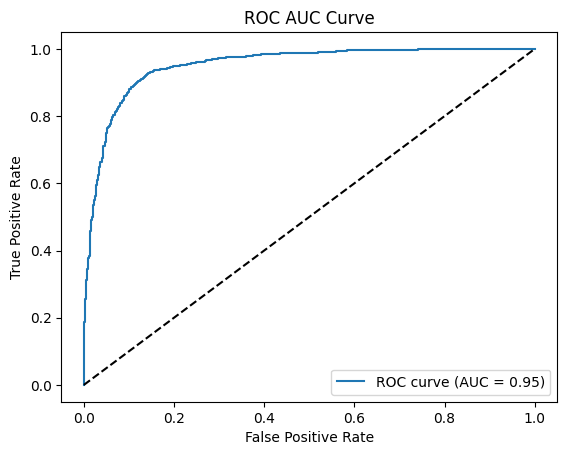

In [13]:

# plot ROC curve
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc_score:.2f})')
plt.plot([0,1],[0,1],'k--')  # diagonal reference line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC AUC Curve')
plt.legend()
plt.show()

In [16]:
# find optimal threshold
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
print("Best threshold:", optimal_threshold)

Best threshold: 0.42386501360657813


In [18]:
y_probs >= 0.42386501360657813

array([ True,  True,  True, ..., False, False, False])

In [19]:
# as the vBest threshold: 0.42386501360657813 so

y_pred_optimal = (y_probs >= 0.42386501360657813).astype(int)

y_pred_optimal

array([1, 1, 1, ..., 0, 0, 0])

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score

print(accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred_optimal))
print(classification_report(y_test, y_pred_optimal))

In [23]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# BEFORE - default threshold (0.5)
y_pred_default = model.predict(X_test)  # uses 0.5 threshold internally

print("=== Default Threshold (0.5) ===")
print("Accuracy:", accuracy_score(y_test, y_pred_default))
print(confusion_matrix(y_test, y_pred_default))
print(classification_report(y_test, y_pred_default))

# AFTER - optimal threshold
y_pred_optimal = (y_probs >= 0.42386501360657813).astype(int)

print("=== Optimal Threshold (0.4239) ===")
print("Accuracy:", accuracy_score(y_test, y_pred_optimal))
print(confusion_matrix(y_test, y_pred_optimal))
print(classification_report(y_test, y_pred_optimal))

=== Default Threshold (0.5) ===
Accuracy: 0.8903333333333333
[[1334  171]
 [ 158 1337]]
              precision    recall  f1-score   support

           0       0.89      0.89      0.89      1505
           1       0.89      0.89      0.89      1495

    accuracy                           0.89      3000
   macro avg       0.89      0.89      0.89      3000
weighted avg       0.89      0.89      0.89      3000

=== Optimal Threshold (0.4239) ===
Accuracy: 0.8926666666666667
[[1293  212]
 [ 110 1385]]
              precision    recall  f1-score   support

           0       0.92      0.86      0.89      1505
           1       0.87      0.93      0.90      1495

    accuracy                           0.89      3000
   macro avg       0.89      0.89      0.89      3000
weighted avg       0.89      0.89      0.89      3000

